In [1]:
import pandas as pd

# Load the dataset
file_path = "gastric_cancer_data.csv"
df = pd.read_csv(file_path)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212354 entries, 0 to 212353
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   age                            212354 non-null  int64  
 1   gender                         212354 non-null  object 
 2   ethnicity                      212354 non-null  object 
 3   geographical_location          212354 non-null  object 
 4   family_history                 212354 non-null  int64  
 5   smoking_habits                 212354 non-null  int64  
 6   alcohol_consumption            212354 non-null  int64  
 7   helicobacter_pylori_infection  212354 non-null  int64  
 8   dietary_habits                 212354 non-null  object 
 9   existing_conditions            169868 non-null  object 
 10  endoscopic_images              212354 non-null  object 
 11  biopsy_results                 212354 non-null  object 
 12  ct_scan                       

In [3]:
df.head()

,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,43,Male,Ethnicity_A,Other,1,0,0,0,Low_Salt,Chronic Gastritis,...,0.187003,0.786422,0.204816,0.561920,0.438175,0.283603,0.928244,4.324299,7.666791,0
1,86,Female,Ethnicity_B,California,1,0,0,1,High_Salt,Diabetes,...,0.493322,0.963989,0.498041,0.985585,0.144609,0.375375,0.103573,7.967674,1.483280,0
2,68,Male,Ethnicity_A,California,0,1,1,0,High_Salt,NaN,...,0.573560,0.666896,0.540388,0.905853,0.827279,0.350915,0.166878,3.748651,3.046783,0
3,57,Female,Ethnicity_A,Other,0,0,0,1,High_Salt,Chronic Gastritis,...,0.261399,0.949488,0.134170,0.429935,0.935231,0.794704,0.867036,5.478298,8.811307,0
4,33,Male,Ethnicity_A,California,0,1,1,0,High_Salt,Diabetes,...,0.754478,0.263164,0.876767,0.650832,0.337669,0.427492,0.915804,1.809181,0.394632,0


In [4]:
# categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

In [5]:
from sklearn.preprocessing import LabelEncoder

# apply label encoding 
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le 

In [6]:
df

,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,43,1,0,1,1,0,0,0,1,0,...,0.187003,0.786422,0.204816,0.561920,0.438175,0.283603,0.928244,4.324299,7.666791,0
1,86,0,1,0,1,0,0,1,0,1,...,0.493322,0.963989,0.498041,0.985585,0.144609,0.375375,0.103573,7.967674,1.483280,0
2,68,1,0,0,0,1,1,0,0,2,...,0.573560,0.666896,0.540388,0.905853,0.827279,0.350915,0.166878,3.748651,3.046783,0
3,57,0,0,1,0,0,0,1,0,0,...,0.261399,0.949488,0.134170,0.429935,0.935231,0.794704,0.867036,5.478298,8.811307,0
4,33,1,0,0,0,1,1,0,0,1,...,0.754478,0.263164,0.876767,0.650832,0.337669,0.427492,0.915804,1.809181,0.394632,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212349,47,1,0,0,0,1,1,0,0,0,...,0.408123,0.925035,0.267628,0.538474,0.463471,0.827892,0.929147,0.866260,6.698303,0
212350,59,0,0,0,0,1,1,0,0,0,...,0.578204,0.768279,0.339168,0.236523,0.444216,0.011762,0.053098,5.102216,2.338017,0
212351,58,0,2,0,0,0,0,0,0,2,...,0.940936,0.865221,0.448189,0.899351,0.766615,0.098454,0.384019,7.774612,4.601637,1
212352,77,0,1,0,1,1,0,1,0,0,...,0.498088,0.048195,0.924610,0.101521,0.464988,0.639401,0.410327,2.362698,2.020047,0


In [7]:
df.to_csv("encoded_gastric_cancer_data.csv", index=False)

In [8]:
test_df = df.head(1000)

In [9]:
test_df.to_csv("1000_encoded_gastric_cancer_data.csv", index=False)

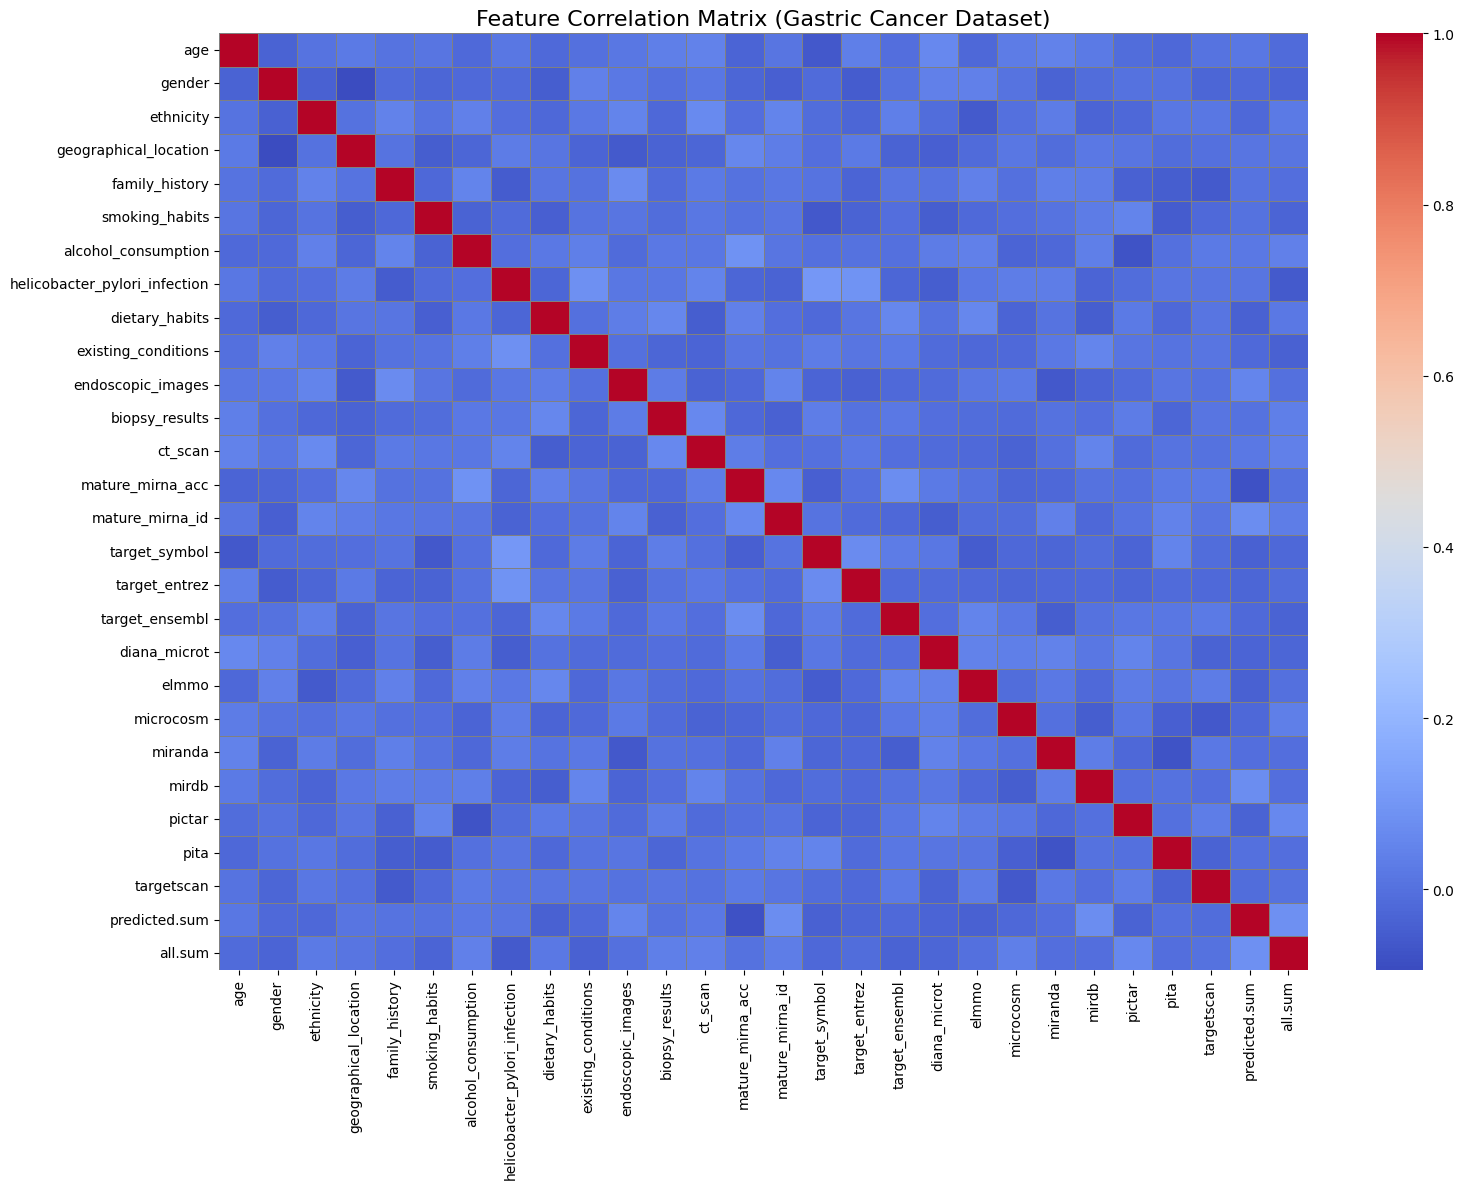

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('1000_encoded_gastric_cancer_data.csv')

# Drop the target column to analyze only the features
features_df = df.drop(columns=df.columns[-1]) 

# Use df2 for EDA on the full dataset file
# df2 = pd.read_csv('encoded_gastric_cancer_data.csv')
# features_df2 = df.drop(columns=df2.columns[-1])

# Compute correlation matrix
corr_matrix = features_df.corr()

# Set plot size and aesthetics
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=False,        # Change to True to show exact values
            cmap='coolwarm', 
            linewidths=0.5, 
            linecolor='gray')

plt.title('Feature Correlation Matrix (Gastric Cancer Dataset)', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

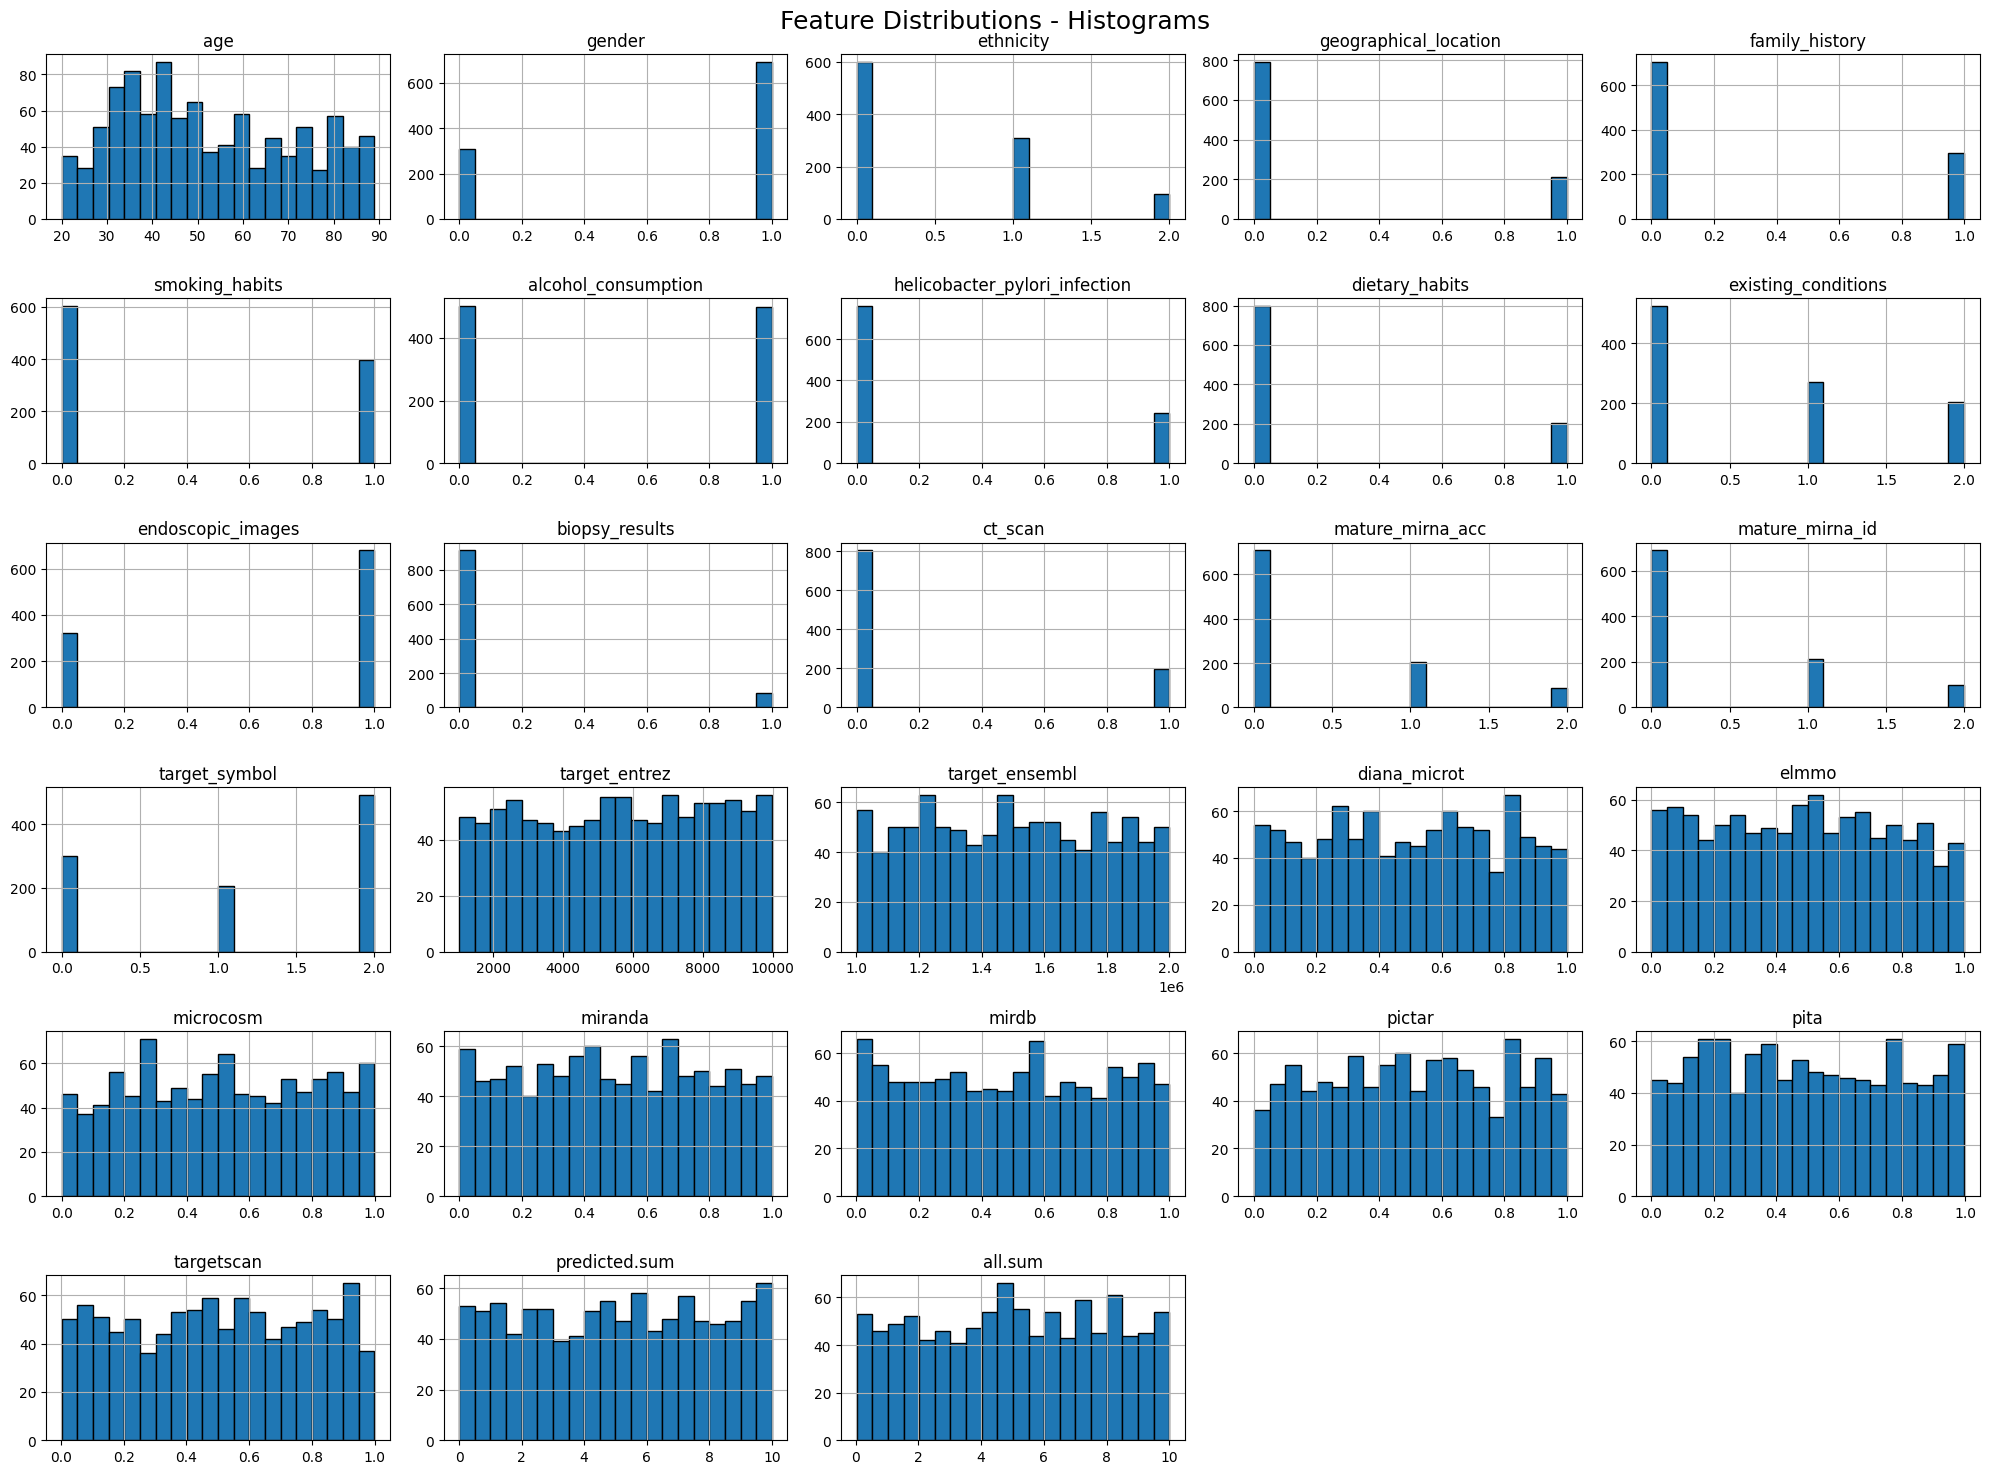

In [11]:

# Plot histograms
features_df.hist(figsize=(20, 15), bins=20, edgecolor='black')
plt.suptitle('Feature Distributions - Histograms', fontsize=18)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


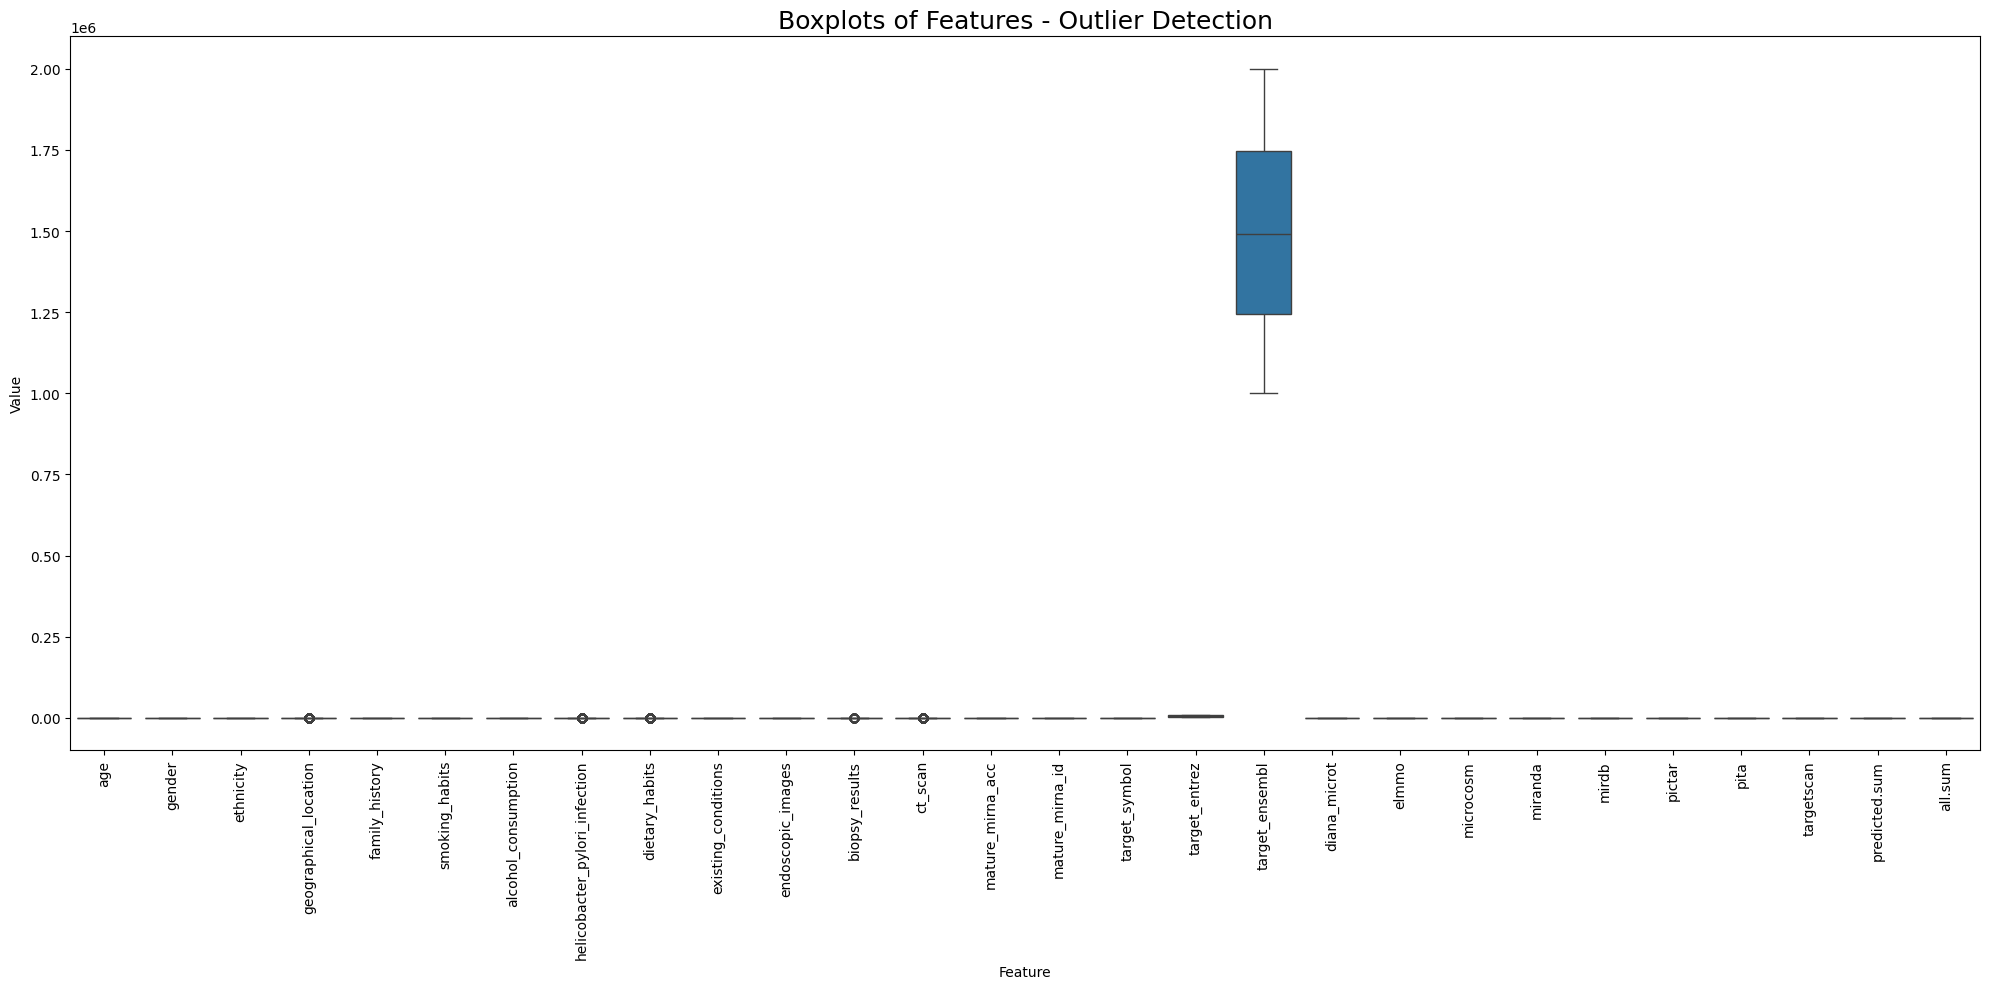

In [15]:
# Melt the dataframe to long format for seaborn boxplot
melted_df = features_df.melt(var_name='Feature', value_name='Value')

plt.figure(figsize=(20, 10))

# Draw boxplots
sns.boxplot(x='Feature', y='Value', data=melted_df)
plt.xticks(rotation=90)
plt.title('Boxplots of Features - Outlier Detection', fontsize=18)
plt.tight_layout()
plt.show()

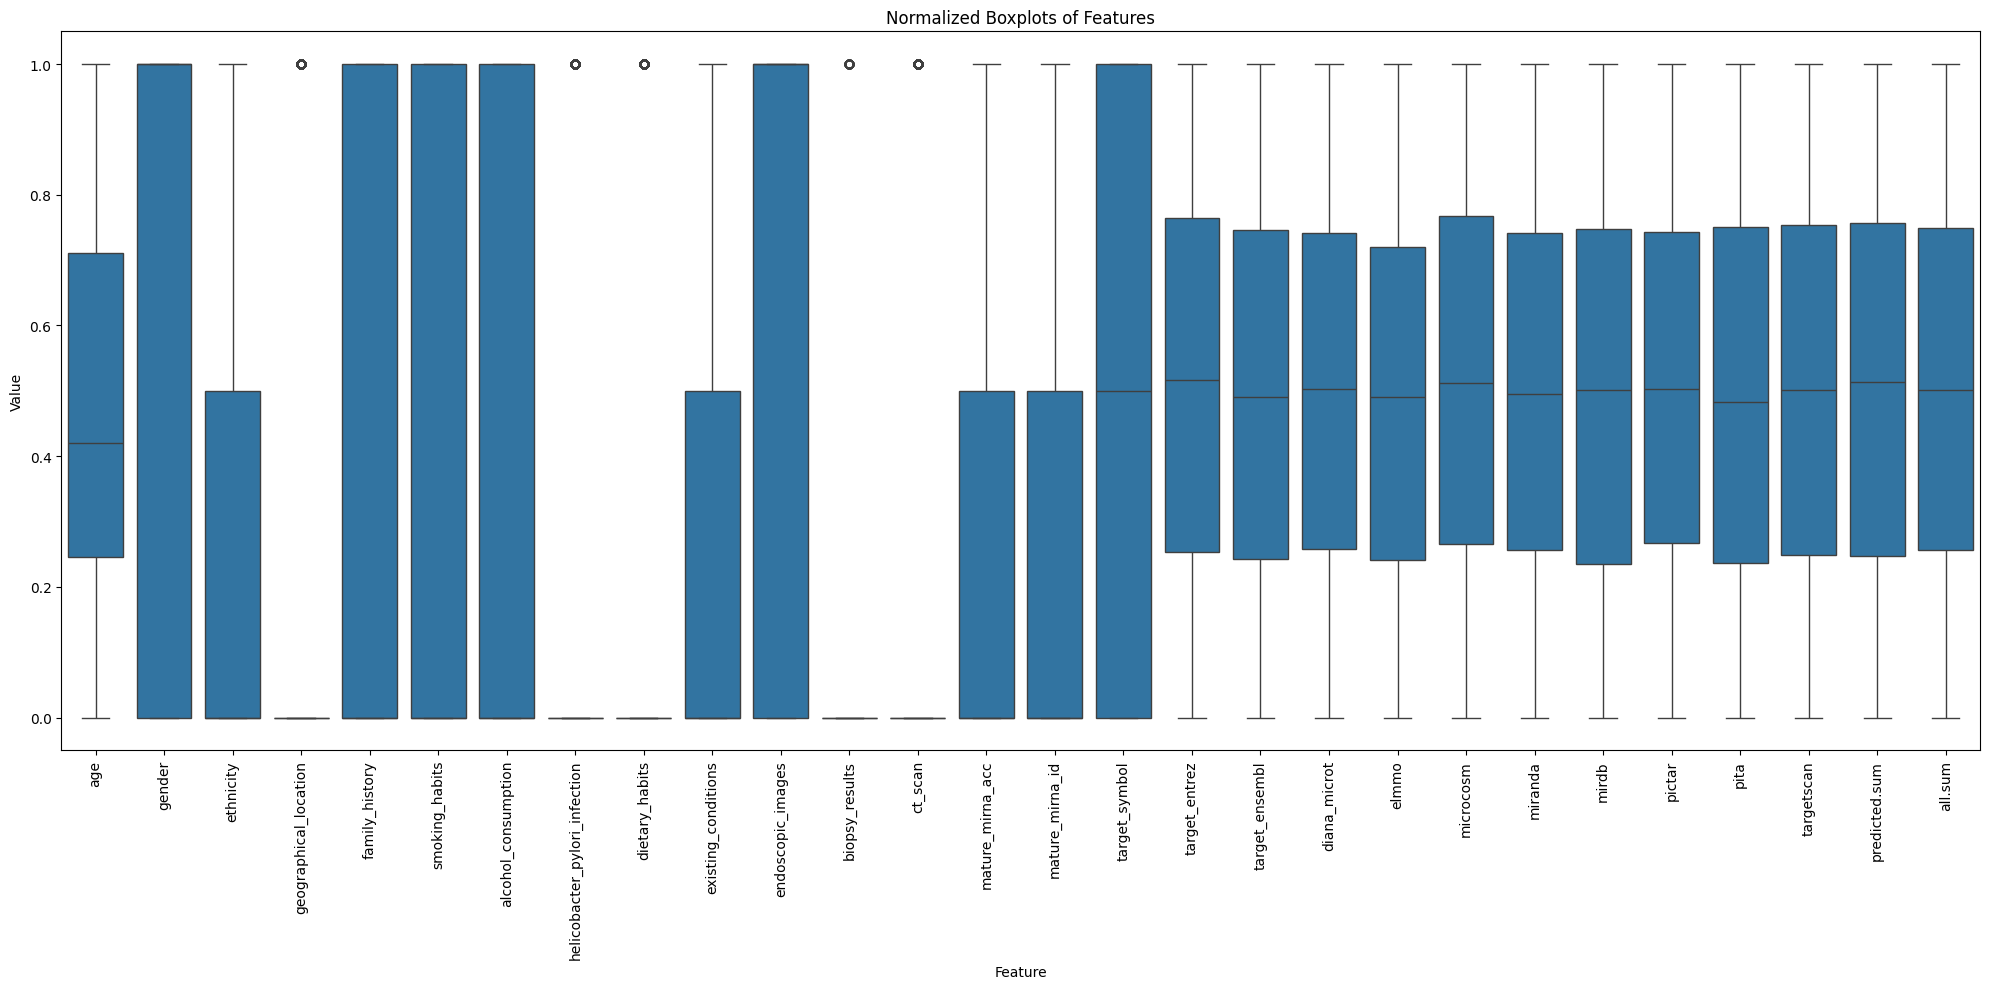

In [16]:
from sklearn.preprocessing import MinMaxScaler

# Normalize features to range [0, 1]
scaler = MinMaxScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(features_df), columns=features_df.columns)

# Melt and plot again
melted_scaled = scaled_df.melt(var_name='Feature', value_name='Value')

plt.figure(figsize=(20, 10))
sns.boxplot(x='Feature', y='Value', data=melted_scaled)
plt.xticks(rotation=90)
plt.title('Normalized Boxplots of Features')
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd

# Load the dataset
file_path = "breast-cancer.csv"
df = pd.read_csv(file_path)

# Encode 'diagnosis': M → 1, B → 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Drop the 'id' column
df = df.drop(columns=['id'])

df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [6]:
diagnosis_col = df.pop('diagnosis')
df['diagnosis'] = diagnosis_col
df

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


In [7]:
df.to_csv("encoded_breast_cancer_data.csv", index=False)